In [1]:
# Chem 277B: Machine Learning Algorithms for
#            Molecular Sciences
#
# Date Created: 11/28/2024
# Last revisited: 11/29/2024


##################################
# FILE FOR RUNNING LSTM MODEL
##################################

'''can use lstm class to tune model parameters
and compare model output to actual data. Different metrics/graphs
and visualizations can be called from the utils file'''






'can use lstm class to tune model parameters\nand compare model output to actual data. Different metrics/graphs\nand visualizations can be called from the utils file'

In [1]:
# imports 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nrsim_lstm import NRSIM_LSTM as lstm
import utils277b as utils
from scope_2 import NuclearReactorSimulator

2024-12-02 15:09:43.671176: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# read data from csv file

#filepath="test_file"
#data = pd.read_csv(filepath)
simulation = NuclearReactorSimulator()
simulation.run_simulation()
data = pd.DataFrame(simulation.normalize_values())
data = data.drop("Time", axis=1)

data.head(5)

,pH,Hydrogen,Total Gas,Temperature,Pressure,Radioactivity,Power,Reactor Safety,Injection of Air,Resin Overheat,Fuel Element Failure,Chemical Addition,Vent Gas
0,0.703545,0.957831,0.746742,0.225806,0.346566,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.701905,0.959992,0.749034,0.237624,0.364704,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.700265,0.962153,0.751325,0.249410,0.382792,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.698625,0.964307,0.753609,0.261130,0.400781,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.696985,0.966447,0.755878,0.272754,0.418621,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
#n_past = int(data.shape[0] * 0.5)
#m_future = data.shape[0] - n_past
n_past = 200
m_future = 200 
display(n_past)
display(m_future)

200

200

In [4]:
data.shape

(4321, 13)

In [5]:
features = 13
X, y = utils.prep_lstm_data(np.array(data), n_past, m_future)

In [6]:
X = X.squeeze()
y = y.squeeze()

In [7]:
# # setting up training data

# n_past = 100
# m_future = 50
# features = 1

# target_param = "Injection of Air"

# # t represents time steps
# t = data["Time"].values
# t = t.reshape(len(t), 1)

# # y(t) is the value of the target parameter at time t
# y_t = data[target_param].values
# y_t = y_t.reshape(len(y_t), 1)

# scaler, y_t_normalized = utils.scale(y_t)

# # creating training and testing data
# X, y = utils.prep_lstm_data(y_t_normalized, n_past, m_future)

# split_point = int(0.8 * len(data))
# X = np.array(data.iloc[:split_point, :])
# Y = np.array(data.iloc[:split_point, :])


#plt.plot(range(0, y.shape[0]), y)
#plt.xlabel("Time")
#plt.ylabel(f"{target_param}")
#plt.title(f"Nuclear Reactor Simulation {target_param} vs Time")
#plt.show()

In [8]:
# each shape[1] value corresponds to the number of points in the past 
# and number of points in the future for X and y, respectively

print(X.shape, y.shape)

(3922, 200, 13) (3922, 200, 13)


In [9]:
# train test splitting data

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

In [ ]:
# model setup 

# stacked lstm layers
neurons = [12, 6]
activation = "tanh"

# temporal params
n_past_timesteps = X.shape[1]
n_features = X.shape[2]
n_predicted_timesteps = y.shape[1]

# optimization + metrics
optimizer = "adam"
loss = "mse"
metrics =["mae", "mse", "rmse"]

# convolutional layer
conv_layer = False
nfilters = 64  
conv_act = 'relu' 
pool_size = 2  
dropout=0.2


my_model = lstm(
    neurons,
    activation,
    n_past_timesteps,
    n_features,
    n_predicted_timesteps,
    optimizer,
    loss,
    metrics,
    dropout,
    conv_layer,
    nfilters,
    conv_act,
    pool_size
)

2024-12-02 15:10:01.985287: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.
2024-12-02 15:10:02.358804: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-12-02 15:10:02.360387: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-12-02 15:10:02.3

In [11]:
my_model.model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 200, 12)           1248      
                                                                 
 dropout (Dropout)           (None, 200, 12)           0         
                                                                 
 lstm_1 (LSTM)               (None, 200, 6)            456       
                                                                 
 dropout_1 (Dropout)         (None, 200, 6)            0         
                                                                 
 dense (Dense)               (None, 200, 13)           91        
                                                                 
Total params: 1,795
Trainable params: 1,795
Non-trainable params: 0
_________________________________________________________________


In [12]:
# fitting model on training data

n_epochs = 20
batch_size = 32


my_model.fit(X_train, y_train, nEpochs=n_epochs, nBatches=batch_size, val_split=0.2, verb=2, shuf=False)


Epoch 1/20


2024-12-02 15:10:07.441113: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-12-02 15:10:07.444688: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-12-02 15:10:07.447436: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

74/74 - 38s - loss: 0.1822 - mae: 0.2855 - mse: 0.1822 - accuracy: 0.0321 - val_loss: 0.1563 - val_mae: 0.2677 - val_mse: 0.1563 - val_accuracy: 0.0876 - 38s/epoch - 508ms/step
Epoch 2/20
74/74 - 29s - loss: 0.1170 - mae: 0.2304 - mse: 0.1170 - accuracy: 0.2842 - val_loss: 0.1077 - val_mae: 0.2219 - val_mse: 0.1077 - val_accuracy: 0.3015 - 29s/epoch - 398ms/step
Epoch 3/20
74/74 - 28s - loss: 0.0872 - mae: 0.1975 - mse: 0.0872 - accuracy: 0.3792 - val_loss: 0.0924 - val_mae: 0.2060 - val_mse: 0.0924 - val_accuracy: 0.3026 - 28s/epoch - 372ms/step
Epoch 4/20
74/74 - 29s - loss: 0.0779 - mae: 0.1873 - mse: 0.0779 - accuracy: 0.3985 - val_loss: 0.0894 - val_mae: 0.1995 - val_mse: 0.0894 - val_accuracy: 0.3034 - 29s/epoch - 388ms/step
Epoch 5/20
74/74 - 27s - loss: 0.0739 - mae: 0.1818 - mse: 0.0739 - accuracy: 0.4024 - val_loss: 0.0883 - val_mae: 0.1959 - val_mse: 0.0883 - val_accuracy: 0.3048 - 27s/epoch - 371ms/step
Epoch 6/20
74/74 - 33s - loss: 0.0711 - mae: 0.1771 - mse: 0.0711 - acc

In [13]:
X.shape

(3922, 200, 13)

In [14]:
# model history

out = my_model.get_model().history



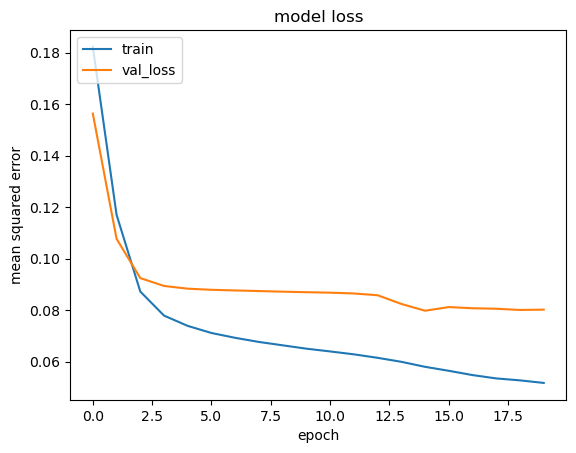

In [15]:
# plotting loss during training
plt.plot(out.history['loss'])
plt.plot(out.history['val_loss'])
plt.title('model loss')
plt.ylabel('mean squared error')
plt.xlabel('epoch')
plt.legend(['train', 'val_loss'], loc = 'upper left')
plt.savefig('training loss.pdf')
plt.show()


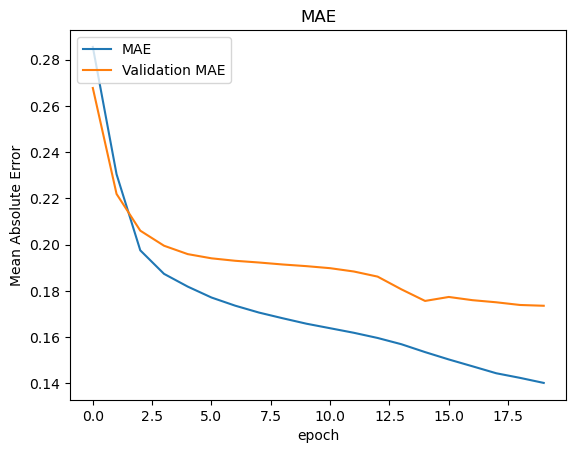

In [17]:
# plot metrics
plt.plot(out.history['mae'])
plt.plot(out.history['val_mae'])
plt.title('MAE')
plt.ylabel('Mean Absolute Error')
plt.xlabel('epoch')
plt.legend(['MAE', 'Validation MAE'], loc = 'upper left')
plt.savefig('training loss.pdf')
plt.show()

In [18]:
y_train.shape

(2941, 200, 13)

In [19]:
def graph_features(data, safety_features = ["Reactor Safety", "Injection of Air", "Resin Overheat", "Fuel Element Failure"]):
    colors = plt.rcParams["axes.prop_cycle"]()
    df = data
    fig, axs = plt.subplots(len(safety_features), figsize=(10,8))
    fig.suptitle('Simulated Reactor Safety Over Time')
    for i in range(len(safety_features)): 
        c = next(colors)["color"]
        x = safety_features[i]
        axs[i].plot(range(0, df.shape[0]), df[:,i], color = c)
        axs[i].set_title(x)
        axs[i].set_xlabel("Time (miliseconds)")
        
    plt.subplots_adjust(wspace=1, hspace=3)

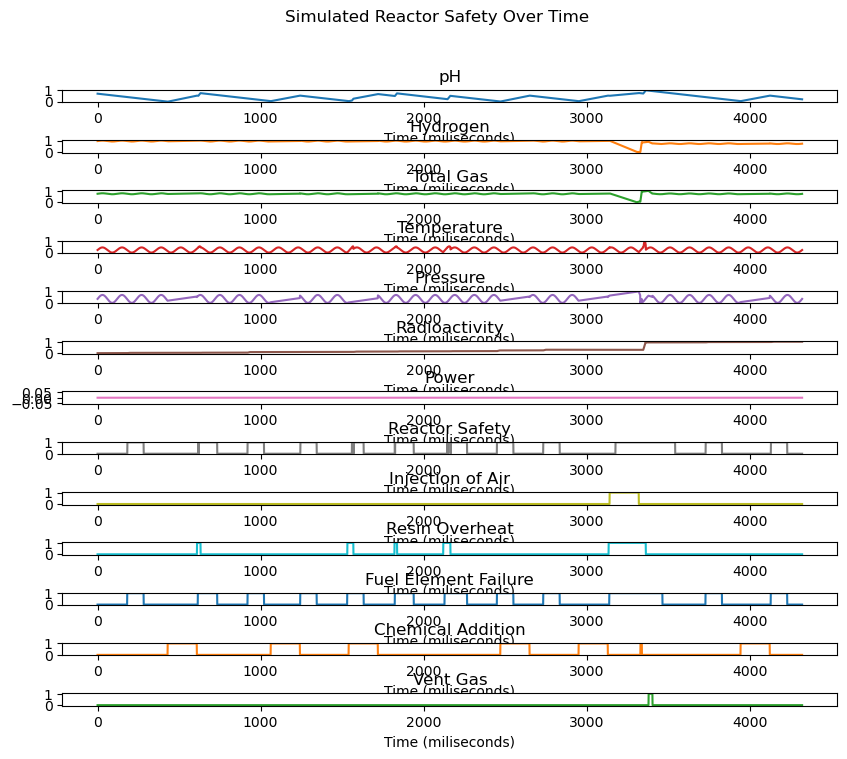

In [20]:
graph_features(np.array(data), safety_features = data.columns)

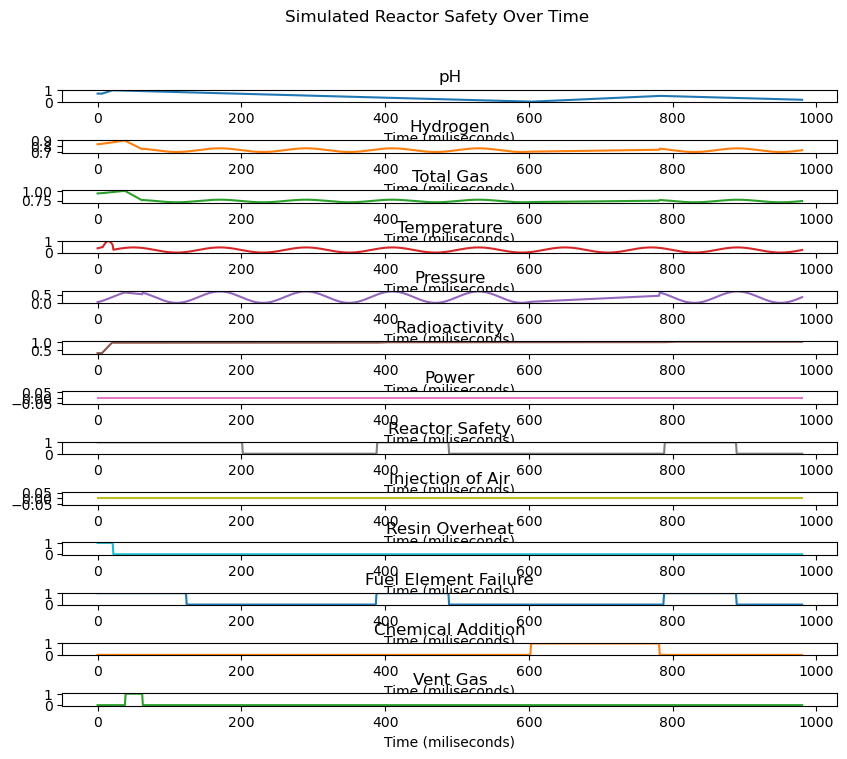

In [25]:
graph_features(y_test[:,199,:], safety_features=data.columns)

In [21]:
y_pred_normalized = my_model.predict(X_test)

2024-12-02 15:21:50.227364: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-12-02 15:21:50.229795: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-12-02 15:21:50.231638: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

31/31 [==============================] - 4s 92ms/step


In [23]:
y_pred_normalized.shape

(981, 200, 13)

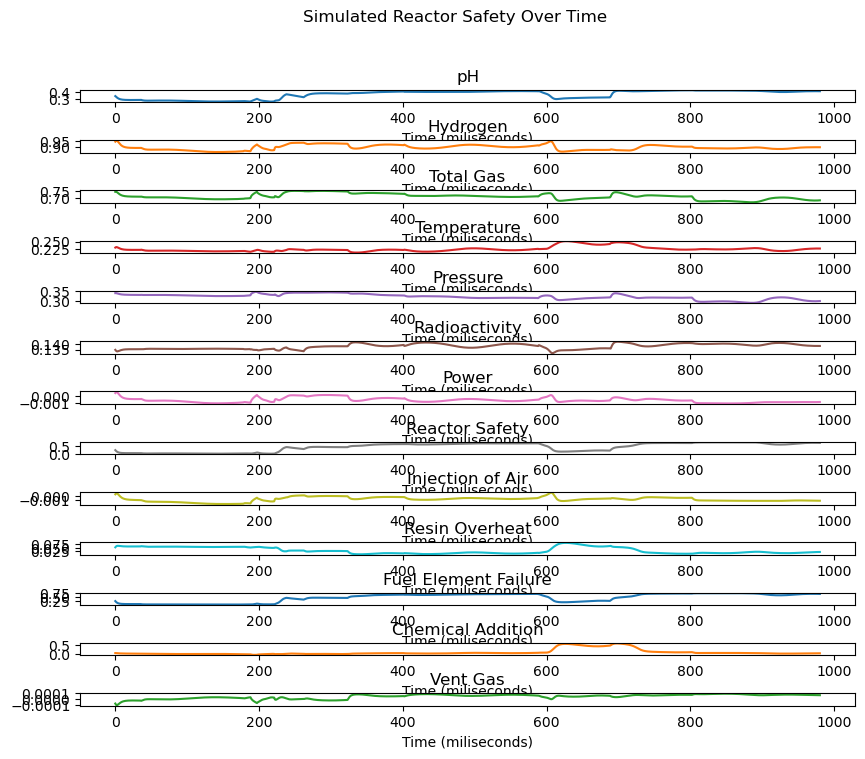

In [24]:
graph_features(y_pred_normalized[:, 199, :], safety_features = data.columns)

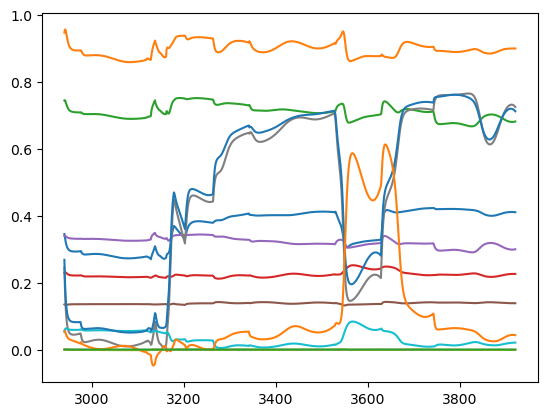

In [28]:
plt.plot(t[-back:], y_pred[:, m_future-1,:])

In [36]:
print(y_train.shape, y_test.shape)

(2941, 200, 13) (981, 200, 13)


In [45]:
y_t.shape[0]

3922

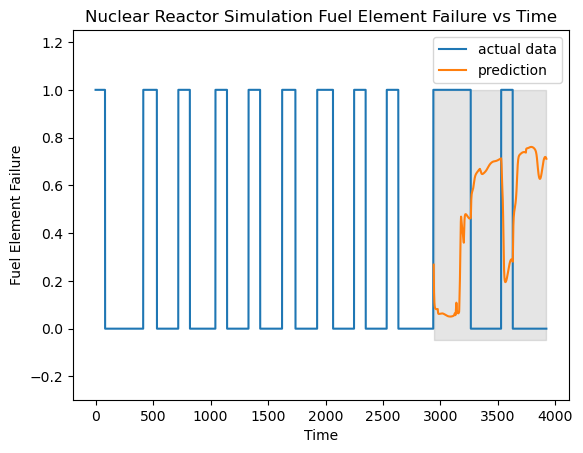

In [57]:
# predicting + transforming normalized data 
back  = y_pred_normalized.shape[0]
y_pred = y_pred_normalized
y_t = y[:, 0, :]
t = range(0,y.shape[0])
# setting bounds for graph
y_min = min(np.min(y_pred), np.min(y_t)) 
y_max = max(np.max(y_pred), np.max(y_t))
plt.ylim(y_min - 0.25, y_max + 0.25)

parameter_i = 10

# plot
plt.plot(t, y_t[:, parameter_i])
plt.plot(t[-back:], y_pred[:, m_future-1, parameter_i])
plt.legend(['actual data', 'prediction'])
plt.fill_between([y_train.shape[0], y_t.shape[0]], y_min, y_max , color = 'k', alpha = 0.1)
#plt.plot([t[-back,0], t[-back,0]], [y_min, y_max ], 'k-')
plt.xlabel("Time")
plt.ylabel(f"{data.columns[parameter_i]}")
plt.title(f"Nuclear Reactor Simulation {data.columns[parameter_i]} vs Time")
plt.show()

In [40]:
y_pred.shape

(1043, 50)

33/33 [==============================] - 2s 56ms/step


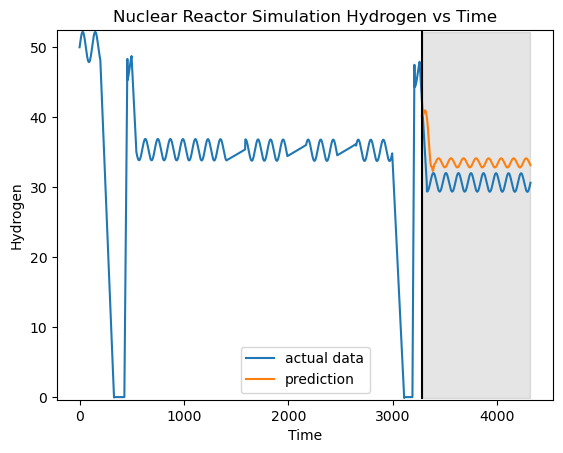

In [22]:
# predicting + transforming normalized data 
y_pred_normalized = my_model.predict(X_test)
back  = y_pred_normalized.shape[0]
y_pred = scaler.inverse_transform(y_pred_normalized)

# setting bounds for graph
y_min = min(np.min(y_pred), np.min(y_t)) 
y_max = max(np.max(y_pred), np.max(y_t))
plt.ylim(y_min - 0.25, y_max + 0.25)

# plot
plt.plot(t, y_t)
plt.plot(t[-back:], y_pred[:, m_future-1])
plt.legend(['actual data', 'prediction'])
plt.fill_between([t[-back,0], t[-1,0]], y_min, y_max , color = 'k', alpha = 0.1)
plt.plot([t[-back,0], t[-back,0]], [y_min, y_max ], 'k-')
plt.xlabel("Time")
plt.ylabel(f"{target_param}")
plt.title(f"Nuclear Reactor Simulation {target_param} vs Time")
plt.show()